# Bayesian Gene Expression Estimation: Inferring an Unknown Scalar

## Real-World Scenario: HER2 Quantification in Breast Cancer Diagnostics

**Based on Section 3.3.3 of "Probabilistic Machine Learning: An Introduction" by Kevin Murphy**

---

### The Problem

A molecular diagnostics lab needs to quantify **HER2 (ERBB2)** gene expression in a breast tumor biopsy using qPCR. The true log₂ fold-change $z$ relative to normal tissue is unknown, but we have:

1. **Prior knowledge**: From published genomic studies, HER2-positive tumors typically show a log₂ fold-change around 3.0 with known variability across patients
2. **Noisy measurements**: Replicate qPCR ΔΔCt values provide estimates of the fold-change, each corrupted by technical noise

The clinical stakes are high: if HER2 is sufficiently overexpressed, the patient qualifies for **targeted therapy (trastuzumab)**.

### The Mathematical Model

From Section 3.3.3, we model this as a **Linear Gaussian System**:

**Prior on the unknown expression level:**
$$p(z) = \mathcal{N}(z | \mu_0, \lambda_0^{-1})$$

**Likelihood of each qPCR measurement:**
$$p(y_i | z) = \mathcal{N}(y_i | z, \lambda_y^{-1})$$

where $\lambda_0$ is the prior precision and $\lambda_y = 1/\sigma^2$ is the measurement precision.

**Posterior after N measurements (Equation 3.52-3.54):**
$$p(z | \mathbf{y}) = \mathcal{N}(z | \mu_N, \lambda_N^{-1})$$

$$\lambda_N = \lambda_0 + N\lambda_y$$

$$\mu_N = \frac{N\lambda_y \bar{y} + \lambda_0 \mu_0}{\lambda_N} = \frac{N\lambda_y}{N\lambda_y + \lambda_0}\bar{y} + \frac{\lambda_0}{N\lambda_y + \lambda_0}\mu_0$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Setting Up the Scenario

Let's define our HER2 gene expression quantification problem:

In [2]:
# TRUE (unknown) log2 fold-change we want to estimate
TRUE_LOG2FC = 3.2  # True log2 fold-change (~9.2x overexpression vs normal tissue)

# Prior belief (from published genomic studies on HER2+ breast cancer)
mu_0 = 3.0         # Prior mean: literature suggests log2FC ≈ 3.0 for HER2+ tumors
sigma_0 = 1.0      # Prior std: variability across patients and studies
lambda_0 = 1 / sigma_0**2  # Prior precision

# qPCR measurement characteristics
sigma_y = 0.5      # Measurement noise std (typical qPCR technical variability in ΔΔCt)
lambda_y = 1 / sigma_y**2  # Measurement precision

print("=" * 60)
print("HER2 GENE EXPRESSION QUANTIFICATION SETUP")
print("=" * 60)
print(f"\nTrue log₂ fold-change (unknown to us): {TRUE_LOG2FC}")
print(f"  (corresponds to {2**TRUE_LOG2FC:.1f}x overexpression)")
print(f"\nPrior belief (from published studies):")
print(f"  - Expected log₂FC: μ₀ = {mu_0}")
print(f"  - Prior uncertainty: σ₀ = {sigma_0}")
print(f"  - Prior precision: λ₀ = {lambda_0:.4f}")
print(f"\nqPCR measurement characteristics:")
print(f"  - Technical noise: σ_y = {sigma_y} (ΔΔCt units)")
print(f"  - Measurement precision: λ_y = {lambda_y:.4f}")

HER2 GENE EXPRESSION QUANTIFICATION SETUP

True log₂ fold-change (unknown to us): 3.2
  (corresponds to 9.2x overexpression)

Prior belief (from published studies):
  - Expected log₂FC: μ₀ = 3.0
  - Prior uncertainty: σ₀ = 1.0
  - Prior precision: λ₀ = 1.0000

qPCR measurement characteristics:
  - Technical noise: σ_y = 0.5 (ΔΔCt units)
  - Measurement precision: λ_y = 4.0000


## 2. Generating Synthetic qPCR Measurements

In [3]:
# Generate N noisy qPCR ΔΔCt readings
N_measurements = 20
measurements = np.random.normal(TRUE_LOG2FC, sigma_y, N_measurements)

print(f"Collected {N_measurements} qPCR replicate measurements:")
print("-" * 50)
for i, y in enumerate(measurements):
    print(f"  Replicate {i+1:2d}: ΔΔCt = {y:.2f}  ({2**y:.1f}x)")
print("-" * 50)
print(f"  Sample mean: {np.mean(measurements):.2f} (log₂FC)")
print(f"  Sample std:  {np.std(measurements):.2f}")
print(f"  Mean fold-change: {2**np.mean(measurements):.1f}x")

Collected 20 qPCR replicate measurements:
--------------------------------------------------
  Replicate  1: ΔΔCt = 3.45  (10.9x)
  Replicate  2: ΔΔCt = 3.13  (8.8x)
  Replicate  3: ΔΔCt = 3.52  (11.5x)
  Replicate  4: ΔΔCt = 3.96  (15.6x)
  Replicate  5: ΔΔCt = 3.08  (8.5x)
  Replicate  6: ΔΔCt = 3.08  (8.5x)
  Replicate  7: ΔΔCt = 3.99  (15.9x)
  Replicate  8: ΔΔCt = 3.58  (12.0x)
  Replicate  9: ΔΔCt = 2.97  (7.8x)
  Replicate 10: ΔΔCt = 3.47  (11.1x)
  Replicate 11: ΔΔCt = 2.97  (7.8x)
  Replicate 12: ΔΔCt = 2.97  (7.8x)
  Replicate 13: ΔΔCt = 3.32  (10.0x)
  Replicate 14: ΔΔCt = 2.24  (4.7x)
  Replicate 15: ΔΔCt = 2.34  (5.1x)
  Replicate 16: ΔΔCt = 2.92  (7.6x)
  Replicate 17: ΔΔCt = 2.69  (6.5x)
  Replicate 18: ΔΔCt = 3.36  (10.2x)
  Replicate 19: ΔΔCt = 2.75  (6.7x)
  Replicate 20: ΔΔCt = 2.49  (5.6x)
--------------------------------------------------
  Sample mean: 3.11 (log₂FC)
  Sample std:  0.47
  Mean fold-change: 8.7x


## 3. Implementing Bayesian Inference (Section 3.3.3)

Now let's implement the key equations from Section 3.3.3:

In [4]:
def bayesian_update_scalar(measurements, mu_0, lambda_0, lambda_y):
    """
    Bayesian update for inferring an unknown scalar from noisy measurements.
    
    Implements Equations 3.52-3.54 from Murphy's PML book.
    
    Parameters:
    -----------
    measurements : array-like
        Noisy observations y_1, ..., y_N
    mu_0 : float
        Prior mean
    lambda_0 : float
        Prior precision (1/variance)
    lambda_y : float
        Measurement precision (1/noise_variance)
    
    Returns:
    --------
    mu_N : float
        Posterior mean
    lambda_N : float
        Posterior precision
    sigma_N : float
        Posterior standard deviation
    """
    N = len(measurements)
    y_bar = np.mean(measurements)
    
    # Equation 3.53: Posterior precision
    lambda_N = lambda_0 + N * lambda_y
    
    # Equation 3.54: Posterior mean (convex combination of prior and data)
    mu_N = (N * lambda_y * y_bar + lambda_0 * mu_0) / lambda_N
    
    # Convert precision to standard deviation
    sigma_N = np.sqrt(1 / lambda_N)
    
    return mu_N, lambda_N, sigma_N


# Compute posterior
mu_N, lambda_N, sigma_N = bayesian_update_scalar(measurements, mu_0, lambda_0, lambda_y)

print("\n" + "=" * 60)
print("BAYESIAN INFERENCE RESULTS")
print("=" * 60)
print(f"\nPrior: N({mu_0:.2f}, {sigma_0:.2f}²)")
print(f"Posterior: N({mu_N:.2f}, {sigma_N:.2f}²)")
print(f"\nTrue log₂FC: {TRUE_LOG2FC}")
print(f"Posterior mean (estimate): {mu_N:.2f}")
print(f"Estimation error: {abs(mu_N - TRUE_LOG2FC):.2f}")
print(f"\n95% Credible Interval: [{mu_N - 1.96*sigma_N:.2f}, {mu_N + 1.96*sigma_N:.2f}]")
print(f"  → Fold-change range: [{2**(mu_N - 1.96*sigma_N):.1f}x, {2**(mu_N + 1.96*sigma_N):.1f}x]")
print(f"Does interval contain true value? {mu_N - 1.96*sigma_N <= TRUE_LOG2FC <= mu_N + 1.96*sigma_N}")


BAYESIAN INFERENCE RESULTS

Prior: N(3.00, 1.00²)
Posterior: N(3.11, 0.11²)

True log₂FC: 3.2
Posterior mean (estimate): 3.11
Estimation error: 0.09

95% Credible Interval: [2.90, 3.33]
  → Fold-change range: [7.4x, 10.1x]
Does interval contain true value? True


## 4. Visualizing Prior, Likelihood, and Posterior

This visualization mirrors Figure 3.8 from the textbook:

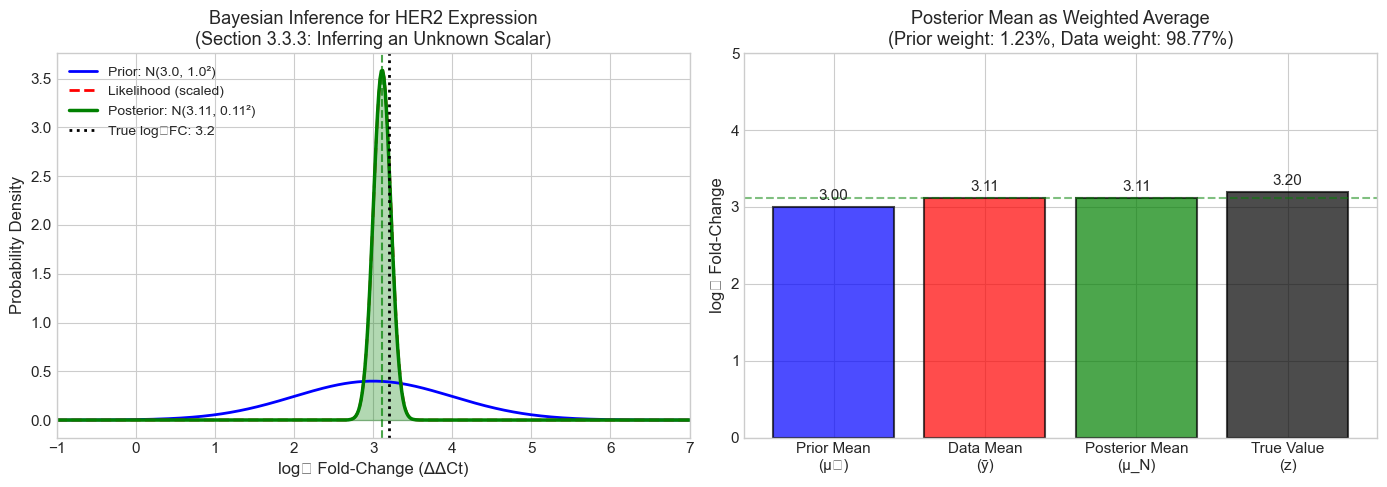


Shrinkage Analysis (Equations 3.61-3.63):
  Weight on prior mean: 1.23%
  Weight on data mean:  98.77%
  μ_N = 0.012 × 3.0 + 0.988 × 3.11 = 3.11


In [5]:
# Create log2FC range for plotting
z_range = np.linspace(-1, 7, 500)

# Prior distribution
prior = stats.norm.pdf(z_range, mu_0, sigma_0)

# Likelihood (as a function of z, given the data mean)
y_bar = np.mean(measurements)
sigma_likelihood = sigma_y / np.sqrt(N_measurements)
likelihood = stats.norm.pdf(z_range, y_bar, sigma_likelihood)

# Posterior distribution
posterior = stats.norm.pdf(z_range, mu_N, sigma_N)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All three distributions
ax1 = axes[0]
ax1.plot(z_range, prior, 'b-', linewidth=2, label=f'Prior: N({mu_0}, {sigma_0}²)')
ax1.plot(z_range, likelihood / likelihood.max() * posterior.max(), 'r--', linewidth=2, 
         label=f'Likelihood (scaled)')
ax1.plot(z_range, posterior, 'g-', linewidth=2.5, label=f'Posterior: N({mu_N:.2f}, {sigma_N:.2f}²)')
ax1.axvline(TRUE_LOG2FC, color='k', linestyle=':', linewidth=2, label=f'True log₂FC: {TRUE_LOG2FC}')
ax1.axvline(mu_N, color='g', linestyle='--', alpha=0.7, linewidth=1.5)

ax1.fill_between(z_range, posterior, alpha=0.3, color='green')
ax1.set_xlabel('log₂ Fold-Change (ΔΔCt)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Bayesian Inference for HER2 Expression\n(Section 3.3.3: Inferring an Unknown Scalar)', fontsize=13)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_xlim(-1, 7)

# Plot 2: Show the shrinkage effect (Equation 3.61-3.63)
ax2 = axes[1]

# Weight on prior vs data
w_prior = lambda_0 / lambda_N
w_data = N_measurements * lambda_y / lambda_N

categories = ['Prior Mean\n(μ₀)', 'Data Mean\n(ȳ)', 'Posterior Mean\n(μ_N)', 'True Value\n(z)']
values = [mu_0, y_bar, mu_N, TRUE_LOG2FC]
colors = ['blue', 'red', 'green', 'black']

bars = ax2.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=mu_N, color='green', linestyle='--', alpha=0.5)

# Add value labels
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

ax2.set_ylabel('log₂ Fold-Change', fontsize=12)
ax2.set_title(f'Posterior Mean as Weighted Average\n(Prior weight: {w_prior:.2%}, Data weight: {w_data:.2%})', fontsize=13)
ax2.set_ylim(0, 5)

plt.tight_layout()
plt.show()

print(f"\nShrinkage Analysis (Equations 3.61-3.63):")
print(f"  Weight on prior mean: {w_prior:.2%}")
print(f"  Weight on data mean:  {w_data:.2%}")
print(f"  μ_N = {w_prior:.3f} × {mu_0} + {w_data:.3f} × {y_bar:.2f} = {mu_N:.2f}")

## 5. Sequential Bayesian Updates

One powerful aspect of Bayesian inference is that we can update our beliefs sequentially as new qPCR replicates arrive (Equations 3.58-3.63). This mirrors how a lab might process samples one at a time:

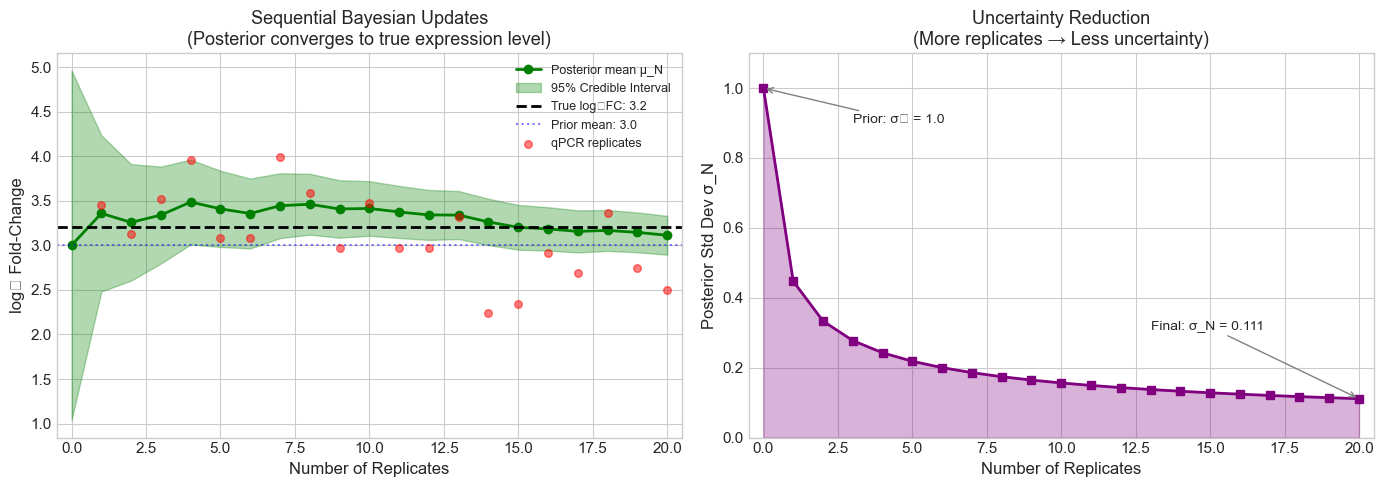


Uncertainty reduction:
  Prior std:     σ₀ = 1.00
  Posterior std: σ_N = 0.111
  Reduction:     88.9%


In [6]:
def sequential_bayesian_update(measurements, mu_0, sigma_0, sigma_y):
    """
    Perform sequential Bayesian updates, one measurement at a time.
    
    Implements the sequential update from Equations 3.58-3.63.
    """
    mu_history = [mu_0]
    sigma_history = [sigma_0]
    
    mu_current = mu_0
    sigma_current = sigma_0
    
    for y in measurements:
        # Sequential update (Equations 3.59-3.60)
        # Posterior variance (Eq 3.59)
        sigma_new_sq = (sigma_y**2 * sigma_current**2) / (sigma_current**2 + sigma_y**2)
        sigma_new = np.sqrt(sigma_new_sq)
        
        # Posterior mean (Eq 3.60) - convex combination
        mu_new = sigma_new_sq * (mu_current / sigma_current**2 + y / sigma_y**2)
        
        mu_current = mu_new
        sigma_current = sigma_new
        
        mu_history.append(mu_current)
        sigma_history.append(sigma_current)
    
    return np.array(mu_history), np.array(sigma_history)


# Perform sequential updates
mu_seq, sigma_seq = sequential_bayesian_update(measurements, mu_0, sigma_0, sigma_y)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_obs = np.arange(len(mu_seq))

# Plot 1: Evolution of posterior mean
ax1 = axes[0]
ax1.plot(n_obs, mu_seq, 'g-o', linewidth=2, markersize=6, label='Posterior mean μ_N')
ax1.fill_between(n_obs, mu_seq - 1.96*sigma_seq, mu_seq + 1.96*sigma_seq, 
                  alpha=0.3, color='green', label='95% Credible Interval')
ax1.axhline(TRUE_LOG2FC, color='black', linestyle='--', linewidth=2, label=f'True log₂FC: {TRUE_LOG2FC}')
ax1.axhline(mu_0, color='blue', linestyle=':', alpha=0.5, label=f'Prior mean: {mu_0}')

# Mark individual measurements
ax1.scatter(n_obs[1:], measurements, color='red', alpha=0.5, s=30, zorder=5, label='qPCR replicates')

ax1.set_xlabel('Number of Replicates', fontsize=12)
ax1.set_ylabel('log₂ Fold-Change', fontsize=12)
ax1.set_title('Sequential Bayesian Updates\n(Posterior converges to true expression level)', fontsize=13)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(-0.5, N_measurements + 0.5)

# Plot 2: Evolution of uncertainty
ax2 = axes[1]
ax2.plot(n_obs, sigma_seq, 'purple', linewidth=2, marker='s', markersize=6)
ax2.fill_between(n_obs, 0, sigma_seq, alpha=0.3, color='purple')

ax2.set_xlabel('Number of Replicates', fontsize=12)
ax2.set_ylabel('Posterior Std Dev σ_N', fontsize=12)
ax2.set_title('Uncertainty Reduction\n(More replicates → Less uncertainty)', fontsize=13)
ax2.set_xlim(-0.5, N_measurements + 0.5)
ax2.set_ylim(0, sigma_0 * 1.1)

# Add annotations
ax2.annotate(f'Prior: σ₀ = {sigma_0:.1f}', xy=(0, sigma_0), 
             xytext=(3, sigma_0 - 0.1), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate(f'Final: σ_N = {sigma_seq[-1]:.3f}', xy=(N_measurements, sigma_seq[-1]), 
             xytext=(N_measurements - 7, sigma_seq[-1] + 0.2), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"\nUncertainty reduction:")
print(f"  Prior std:     σ₀ = {sigma_0:.2f}")
print(f"  Posterior std: σ_N = {sigma_seq[-1]:.3f}")
print(f"  Reduction:     {(1 - sigma_seq[-1]/sigma_0)*100:.1f}%")

## 6. Effect of Prior Strength (Figure 3.8 Recreation)

Section 3.3.3 discusses how the prior strength affects the posterior. In our context: how much should the literature on HER2 expression influence our estimate for this specific patient?

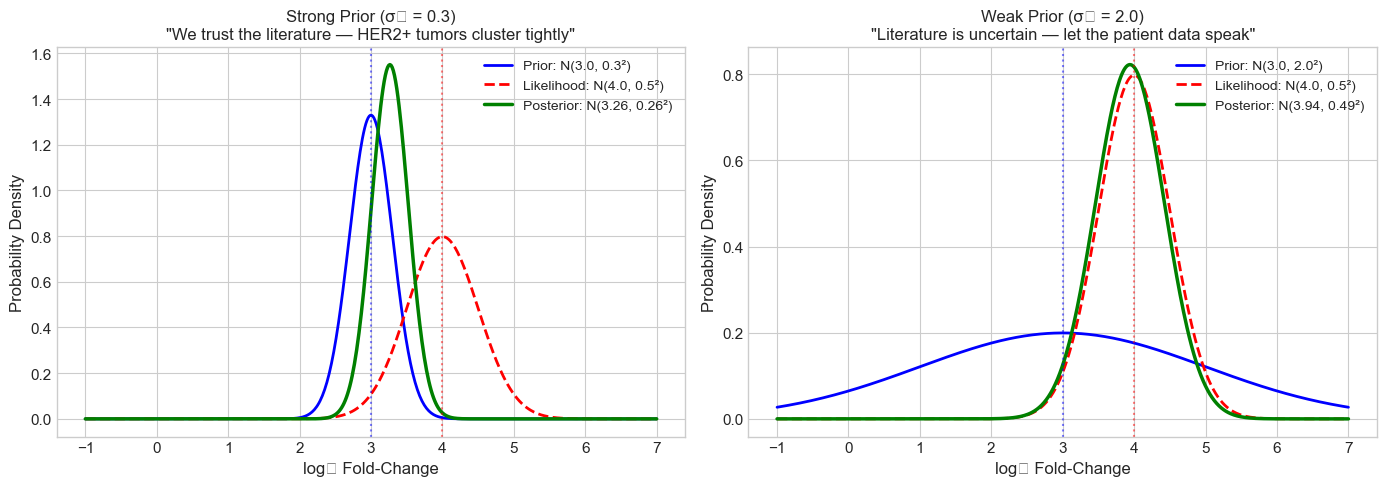


Effect of Prior Strength (single qPCR reading y = 4.0):

  Strong prior (σ₀ = 0.3):
    Posterior mean: 3.26 (shrunk toward prior μ₀ = 3.0)

  Weak prior (σ₀ = 2.0):
    Posterior mean: 3.94 (close to observation y = 4.0)


In [7]:
# Single observation for clarity
y_single = 4.0  # A single qPCR reading showing high expression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_range = np.linspace(-1, 7, 500)

# Strong prior (small variance) — highly confident in literature values
sigma_prior_strong = 0.3
mu_post_strong, _, sigma_post_strong = bayesian_update_scalar(
    [y_single], mu_0, 1/sigma_prior_strong**2, lambda_y
)

ax1 = axes[0]
ax1.plot(z_range, stats.norm.pdf(z_range, mu_0, sigma_prior_strong), 'b-', 
         linewidth=2, label=f'Prior: N({mu_0}, {sigma_prior_strong}²)')
ax1.plot(z_range, stats.norm.pdf(z_range, y_single, sigma_y), 'r--', 
         linewidth=2, label=f'Likelihood: N({y_single}, {sigma_y}²)')
ax1.plot(z_range, stats.norm.pdf(z_range, mu_post_strong, sigma_post_strong), 'g-', 
         linewidth=2.5, label=f'Posterior: N({mu_post_strong:.2f}, {sigma_post_strong:.2f}²)')
ax1.axvline(y_single, color='red', linestyle=':', alpha=0.5)
ax1.axvline(mu_0, color='blue', linestyle=':', alpha=0.5)
ax1.set_xlabel('log₂ Fold-Change', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title(f'Strong Prior (σ₀ = {sigma_prior_strong})\n"We trust the literature — HER2+ tumors cluster tightly"', fontsize=12)
ax1.legend(fontsize=10)

# Weak prior (large variance) — uncertain about literature applicability
sigma_prior_weak = 2.0
mu_post_weak, _, sigma_post_weak = bayesian_update_scalar(
    [y_single], mu_0, 1/sigma_prior_weak**2, lambda_y
)

ax2 = axes[1]
ax2.plot(z_range, stats.norm.pdf(z_range, mu_0, sigma_prior_weak), 'b-', 
         linewidth=2, label=f'Prior: N({mu_0}, {sigma_prior_weak}²)')
ax2.plot(z_range, stats.norm.pdf(z_range, y_single, sigma_y), 'r--', 
         linewidth=2, label=f'Likelihood: N({y_single}, {sigma_y}²)')
ax2.plot(z_range, stats.norm.pdf(z_range, mu_post_weak, sigma_post_weak), 'g-', 
         linewidth=2.5, label=f'Posterior: N({mu_post_weak:.2f}, {sigma_post_weak:.2f}²)')
ax2.axvline(y_single, color='red', linestyle=':', alpha=0.5)
ax2.axvline(mu_0, color='blue', linestyle=':', alpha=0.5)
ax2.set_xlabel('log₂ Fold-Change', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title(f'Weak Prior (σ₀ = {sigma_prior_weak})\n"Literature is uncertain — let the patient data speak"', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nEffect of Prior Strength (single qPCR reading y = {y_single}):")
print(f"\n  Strong prior (σ₀ = {sigma_prior_strong}):")
print(f"    Posterior mean: {mu_post_strong:.2f} (shrunk toward prior μ₀ = {mu_0})")
print(f"\n  Weak prior (σ₀ = {sigma_prior_weak}):")
print(f"    Posterior mean: {mu_post_weak:.2f} (close to observation y = {y_single})")

## 7. Signal-to-Noise Ratio Analysis

Section 3.3.3 introduces the Signal-to-Noise Ratio (SNR) as another way to understand shrinkage (Equation 3.64). In our context, it captures how informative the qPCR measurements are relative to the prior uncertainty:

$$\text{SNR} = \frac{\mathbb{E}[Z^2]}{\mathbb{E}[\epsilon^2]} = \frac{\Sigma_0 + \mu_0^2}{\Sigma_y}$$

Signal-to-Noise Ratio Analysis (Equation 3.64):
Prior variance (Σ₀): 1.00
Prior mean squared (μ₀²): 9.00
Noise variance (Σ_y): 0.25

SNR = (Σ₀ + μ₀²) / Σ_y = 40.00
SNR (dB) = 16.0 dB


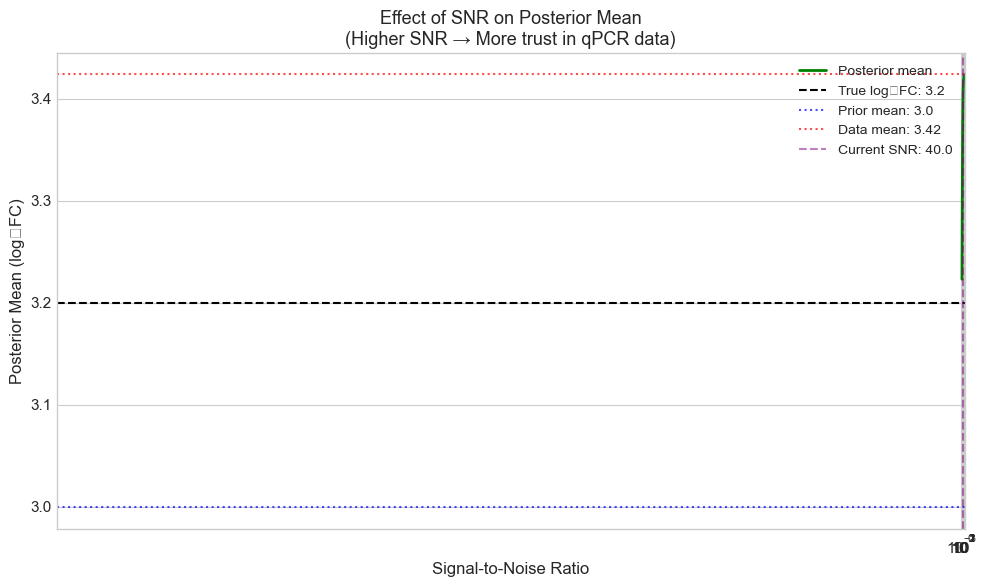

In [8]:
# Calculate SNR
snr = (sigma_0**2 + mu_0**2) / sigma_y**2
snr_db = 10 * np.log10(snr)

print(f"Signal-to-Noise Ratio Analysis (Equation 3.64):")
print(f"=" * 50)
print(f"Prior variance (Σ₀): {sigma_0**2:.2f}")
print(f"Prior mean squared (μ₀²): {mu_0**2:.2f}")
print(f"Noise variance (Σ_y): {sigma_y**2:.2f}")
print(f"\nSNR = (Σ₀ + μ₀²) / Σ_y = {snr:.2f}")
print(f"SNR (dB) = {snr_db:.1f} dB")

# Visualize how different noise levels affect inference
fig, ax = plt.subplots(figsize=(10, 6))

noise_levels = np.linspace(0.1, 3.0, 100)
snr_values = (sigma_0**2 + mu_0**2) / noise_levels**2

# Calculate posterior means for different noise levels (with 10 measurements)
posterior_means = []
for noise in noise_levels:
    mu_post, _, _ = bayesian_update_scalar(measurements[:10], mu_0, lambda_0, 1/noise**2)
    posterior_means.append(mu_post)

ax.plot(snr_values, posterior_means, 'g-', linewidth=2, label='Posterior mean')
ax.axhline(TRUE_LOG2FC, color='black', linestyle='--', label=f'True log₂FC: {TRUE_LOG2FC}')
ax.axhline(mu_0, color='blue', linestyle=':', alpha=0.7, label=f'Prior mean: {mu_0}')
ax.axhline(np.mean(measurements[:10]), color='red', linestyle=':', alpha=0.7, 
           label=f'Data mean: {np.mean(measurements[:10]):.2f}')

ax.axvline(snr, color='purple', linestyle='--', alpha=0.5, label=f'Current SNR: {snr:.1f}')

ax.set_xlabel('Signal-to-Noise Ratio', fontsize=12)
ax.set_ylabel('Posterior Mean (log₂FC)', fontsize=12)
ax.set_title('Effect of SNR on Posterior Mean\n(Higher SNR → More trust in qPCR data)', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, max(snr_values))

ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 8. Clinical Decision: HER2 Status Classification

Let's use our Bayesian estimate to make a clinical treatment decision. In breast cancer diagnostics, HER2 overexpression above a threshold determines eligibility for trastuzumab (Herceptin) therapy:

CLINICAL DECISION: HER2 STATUS

Classification thresholds (log₂ fold-change):
  HER2-negative:  log₂FC < 1.0 (< 2x)
  Equivocal:      1.0 ≤ log₂FC < 2.0 (2x-4x)
  HER2-positive:  log₂FC ≥ 2.0 (≥ 4x)

Bayesian estimate: 3.11 ± 0.22 (95% CI)
  → Fold-change: 8.7x overexpression

Probability of each classification:
  P(HER2-negative):  0.0000%
  P(Equivocal):      0.0000%
  P(HER2-positive):  100.00%

RECOMMENDATION: HER2-POSITIVE — Recommend trastuzumab therapy


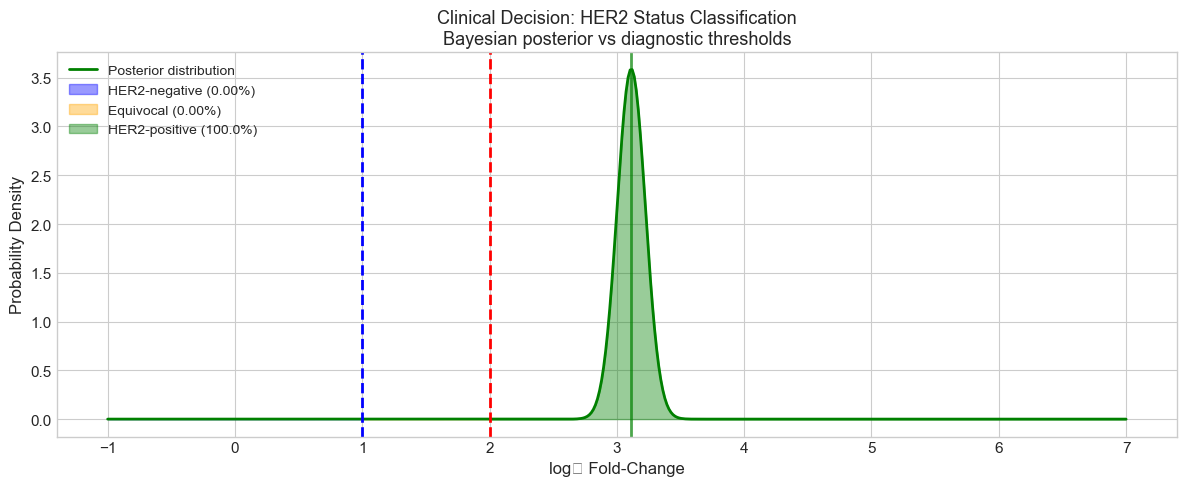

In [9]:
# Clinical thresholds for HER2 classification (log2 fold-change)
THRESHOLD_NEGATIVE = 1.0     # log2FC < 1 → HER2-negative (< 2x overexpression)
THRESHOLD_EQUIVOCAL = 2.0    # 1 ≤ log2FC < 2 → Equivocal (needs FISH confirmation)
THRESHOLD_POSITIVE = 2.0     # log2FC ≥ 2 → HER2-positive (≥ 4x overexpression)

# Calculate probabilities for each clinical category
prob_negative = stats.norm.cdf(THRESHOLD_NEGATIVE, mu_N, sigma_N)
prob_equivocal = stats.norm.cdf(THRESHOLD_POSITIVE, mu_N, sigma_N) - stats.norm.cdf(THRESHOLD_NEGATIVE, mu_N, sigma_N)
prob_positive = 1 - stats.norm.cdf(THRESHOLD_POSITIVE, mu_N, sigma_N)

print("=" * 60)
print("CLINICAL DECISION: HER2 STATUS")
print("=" * 60)
print(f"\nClassification thresholds (log₂ fold-change):")
print(f"  HER2-negative:  log₂FC < {THRESHOLD_NEGATIVE} (< {2**THRESHOLD_NEGATIVE:.0f}x)")
print(f"  Equivocal:      {THRESHOLD_NEGATIVE} ≤ log₂FC < {THRESHOLD_POSITIVE} ({2**THRESHOLD_NEGATIVE:.0f}x-{2**THRESHOLD_POSITIVE:.0f}x)")
print(f"  HER2-positive:  log₂FC ≥ {THRESHOLD_POSITIVE} (≥ {2**THRESHOLD_POSITIVE:.0f}x)")
print(f"\nBayesian estimate: {mu_N:.2f} ± {1.96*sigma_N:.2f} (95% CI)")
print(f"  → Fold-change: {2**mu_N:.1f}x overexpression")
print(f"\nProbability of each classification:")
print(f"  P(HER2-negative):  {prob_negative:.4%}")
print(f"  P(Equivocal):      {prob_equivocal:.4%}")
print(f"  P(HER2-positive):  {prob_positive:.2%}")

# Decision
if prob_positive > 0.95:
    decision = "HER2-POSITIVE — Recommend trastuzumab therapy"
    color = 'green'
elif prob_positive > 0.50:
    decision = "LIKELY POSITIVE — Confirm with FISH before treatment"
    color = 'orange'
else:
    decision = "INSUFFICIENT EVIDENCE — Additional testing required"
    color = 'red'

print(f"\n{'='*60}")
print(f"RECOMMENDATION: {decision}")
print(f"{'='*60}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))

z_range = np.linspace(-1, 7, 500)
posterior_pdf = stats.norm.pdf(z_range, mu_N, sigma_N)

ax.plot(z_range, posterior_pdf, 'g-', linewidth=2, label='Posterior distribution')

# Color regions by clinical classification
ax.fill_between(z_range, posterior_pdf, where=z_range < THRESHOLD_NEGATIVE,
                alpha=0.4, color='blue', label=f'HER2-negative ({prob_negative:.2%})')
ax.fill_between(z_range, posterior_pdf, 
                where=(z_range >= THRESHOLD_NEGATIVE) & (z_range < THRESHOLD_POSITIVE),
                alpha=0.4, color='orange', label=f'Equivocal ({prob_equivocal:.2%})')
ax.fill_between(z_range, posterior_pdf, where=z_range >= THRESHOLD_POSITIVE,
                alpha=0.4, color='green', label=f'HER2-positive ({prob_positive:.1%})')

ax.axvline(THRESHOLD_NEGATIVE, color='blue', linestyle='--', linewidth=2)
ax.axvline(THRESHOLD_POSITIVE, color='red', linestyle='--', linewidth=2)
ax.axvline(mu_N, color='green', linestyle='-', linewidth=2, alpha=0.7)

ax.set_xlabel('log₂ Fold-Change', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Clinical Decision: HER2 Status Classification\nBayesian posterior vs diagnostic thresholds', fontsize=13)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Summary: Key Equations from Section 3.3.3

### The Model
- **Prior**: $p(z) = \mathcal{N}(z | \mu_0, \lambda_0^{-1})$ — Literature-based belief about HER2 expression
- **Likelihood**: $p(y_i | z) = \mathcal{N}(y_i | z, \lambda_y^{-1})$ — Each qPCR replicate measurement

### Posterior After N Observations
$$p(z | \mathbf{y}) = \mathcal{N}(z | \mu_N, \lambda_N^{-1})$$

where:
- **Posterior precision**: $\lambda_N = \lambda_0 + N\lambda_y$ (Eq. 3.53)
- **Posterior mean**: $\mu_N = \frac{N\lambda_y \bar{y} + \lambda_0 \mu_0}{\lambda_N}$ (Eq. 3.54)

### Key Insights
1. **Precision is additive**: More qPCR replicates → more precise expression estimates
2. **Mean is a weighted average**: Posterior balances literature knowledge and patient-specific data
3. **Shrinkage**: Strong priors (e.g., well-characterized biomarkers) pull estimates toward literature values
4. **More data → Less uncertainty**: Posterior variance decreases as $1/(\lambda_0 + N\lambda_y)$
5. **Sequential updates**: Can refine the HER2 estimate as each replicate measurement arrives
6. **Clinical integration**: Posterior probabilities enable principled treatment decisions under uncertainty

In [10]:
# Final summary statistics
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nScenario: HER2 Gene Expression Quantification (Breast Cancer)")
print(f"True log₂FC: {TRUE_LOG2FC} ({2**TRUE_LOG2FC:.1f}x overexpression)")
print(f"Number of qPCR replicates: {N_measurements}")
print(f"\nPrior (literature): μ₀ = {mu_0}, σ₀ = {sigma_0}")
print(f"qPCR noise: σ_y = {sigma_y}")
print(f"\nPosterior: μ_N = {mu_N:.2f}, σ_N = {sigma_N:.3f}")
print(f"95% Credible Interval: [{mu_N - 1.96*sigma_N:.2f}, {mu_N + 1.96*sigma_N:.2f}]")
print(f"  → Fold-change: {2**mu_N:.1f}x [{2**(mu_N - 1.96*sigma_N):.1f}x, {2**(mu_N + 1.96*sigma_N):.1f}x]")
print(f"\nEstimation error: |μ_N - z| = {abs(mu_N - TRUE_LOG2FC):.3f}")
print(f"Uncertainty reduction: {(1 - sigma_N/sigma_0)*100:.1f}%")
print(f"\nClinical: P(HER2-positive) = {prob_positive:.2%}")
print("=" * 70)


FINAL SUMMARY

Scenario: HER2 Gene Expression Quantification (Breast Cancer)
True log₂FC: 3.2 (9.2x overexpression)
Number of qPCR replicates: 20

Prior (literature): μ₀ = 3.0, σ₀ = 1.0
qPCR noise: σ_y = 0.5

Posterior: μ_N = 3.11, σ_N = 0.111
95% Credible Interval: [2.90, 3.33]
  → Fold-change: 8.7x [7.4x, 10.1x]

Estimation error: |μ_N - z| = 0.087
Uncertainty reduction: 88.9%

Clinical: P(HER2-positive) = 100.00%
